# Assignment 14 - Anita Aifesehi

In [30]:
# Loading Data 

import pandas as pd 
import matplotlib.pyplot as plt

In [31]:
# To read the data
df = pd.read_csv(r"C:\Users\anita\OneDrive\Documents\BOOTCAMP_DATA_ANALYTICS\ocd_patient_dataset.csv")

In [32]:
# Top 5 of data
df.head()

,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,NaN


In [33]:
# To check data information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Patient ID                     1500 non-null   int64 
 1   Age                            1500 non-null   int64 
 2   Gender                         1500 non-null   object
 3   Ethnicity                      1500 non-null   object
 4   Marital Status                 1500 non-null   object
 5   Education Level                1500 non-null   object
 6   OCD Diagnosis Date             1500 non-null   object
 7   Duration of Symptoms (months)  1500 non-null   int64 
 8   Previous Diagnoses             1252 non-null   object
 9   Family History of OCD          1500 non-null   object
 10  Obsession Type                 1500 non-null   object
 11  Compulsion Type                1500 non-null   object
 12  Y-BOCS Score (Obsessions)      1500 non-null   int64 
 13  Y-B

In [34]:
# To check duplicate data values
df.duplicated().sum()

0

In [40]:
# To check data statistics
df.describe()

,Patient ID,Age,Duration of Symptoms (months),Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions)
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,5541.254000,46.781333,121.745333,20.048000,19.62600
std,2562.389469,16.830321,67.404610,11.823884,11.78287
min,1017.000000,18.000000,6.000000,0.000000,0.00000
25%,3338.000000,32.000000,64.000000,10.000000,9.00000
50%,5539.500000,47.000000,121.000000,20.000000,20.00000
75%,7745.500000,61.000000,178.000000,31.000000,29.00000
max,9995.000000,75.000000,240.000000,40.000000,40.00000


In [48]:
# To check for missing values
df.isnull().sum()

Patient ID                         0
Age                                0
Gender                             0
Ethnicity                          0
Marital Status                     0
Education Level                    0
OCD Diagnosis Date                 0
Duration of Symptoms (months)      0
Previous Diagnoses               248
Family History of OCD              0
Obsession Type                     0
Compulsion Type                    0
Y-BOCS Score (Obsessions)          0
Y-BOCS Score (Compulsions)         0
Depression Diagnosis               0
Anxiety Diagnosis                  0
Medications                      386
dtype: int64

In [62]:
# Remove rows where Previous Diagnoses or Medications is missing
df = df.dropna(subset=['Previous Diagnoses', 'Medications'])

In [64]:
# To confirm missing values status
df.isnull().sum()

Patient ID                       0
Age                              0
Gender                           0
Ethnicity                        0
Marital Status                   0
Education Level                  0
OCD Diagnosis Date               0
Duration of Symptoms (months)    0
Previous Diagnoses               0
Family History of OCD            0
Obsession Type                   0
Compulsion Type                  0
Y-BOCS Score (Obsessions)        0
Y-BOCS Score (Compulsions)       0
Depression Diagnosis             0
Anxiety Diagnosis                0
Medications                      0
dtype: int64

### Bar Chart:

In [12]:
# 1. A bar chart comparing a numeric column across categories 

# Calculate average obsession score by gender
avg_score = df.groupby('Gender')['Y-BOCS Score (Obsessions)'].mean()
print(avg_score)

Gender
Female    19.971800
Male      20.155172
Name: Y-BOCS Score (Obsessions), dtype: float64


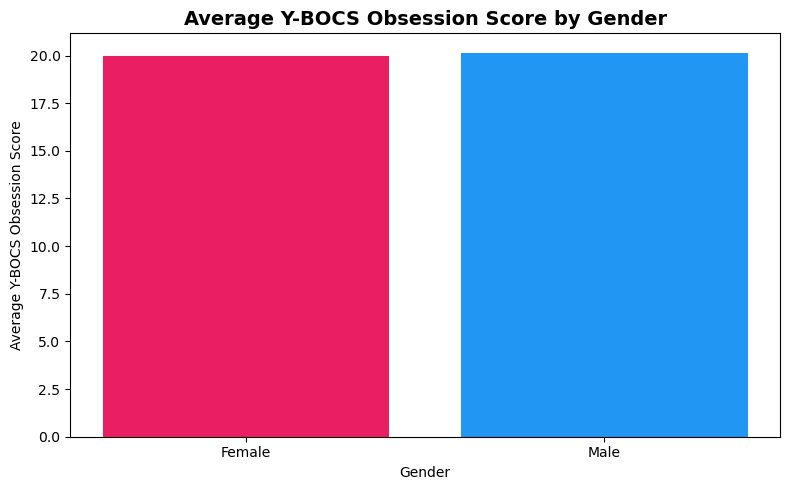

In [13]:
# Create bar chart

plt.figure(figsize=(8,5))

plt.bar(avg_score.index, avg_score.values,
         color=['#E91E63', '#2196F3'])

plt.title('Average Y-BOCS Obsession Score by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Y-BOCS Obsession Score')

plt.tight_layout()

plt.show()

### Line Chart:

In [15]:
# 2. A line chart showing a trend across a sequence

# Create age groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

# Calculate average Y-BOCS obsession score by age group
agegroup_score = df.groupby('AgeGroup', observed=False)['Y-BOCS Score (Obsessions)'].mean()

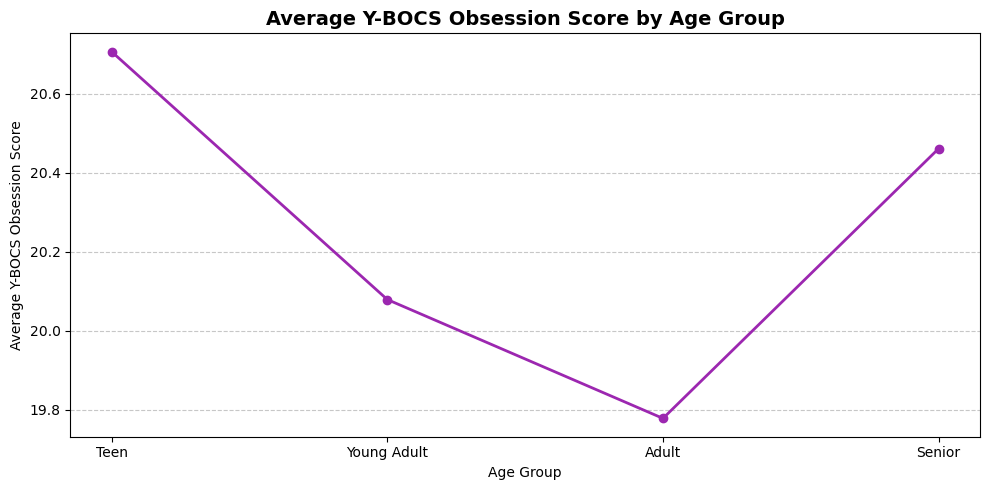

In [16]:
# Create line chart

plt.figure(figsize=(10, 5))

plt.plot(
    agegroup_score.index,
    agegroup_score.values,
    marker='o',
    color='#9C27B0',
    linewidth=2
)

plt.title('Average Y-BOCS Obsession Score by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Y-BOCS Obsession Score')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Histogram Chart:

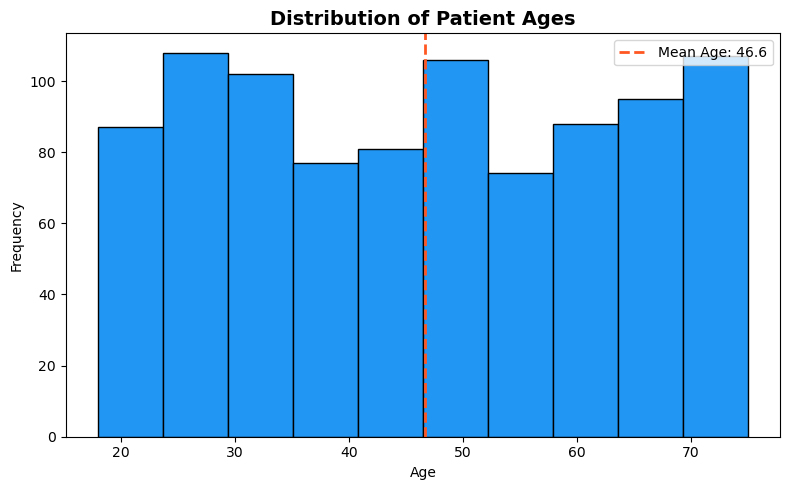

In [18]:
# 3. A histogram with a vertical line marking the mean

# Calculate the mean age
mean_age = df['Age'].mean()

plt.figure(figsize=(8, 5))

plt.hist(
    df['Age'],
    bins=10,
    color='#2196F3',
    edgecolor='black'
)

# Add vertical line for the mean
plt.axvline(
    mean_age,
    color='#FF5722',
    linestyle='--',
    linewidth=2,
    label=f'Mean Age: {mean_age:.1f}'
)

plt.title('Distribution of Patient Ages', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.legend()
plt.tight_layout()
plt.show()

### Pie Chart:

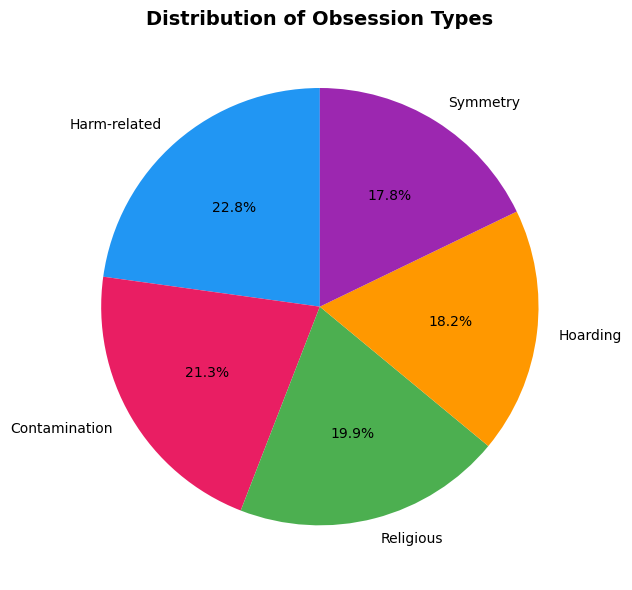

In [20]:
# 4. A pie chart (maximum 6 categories)

# Count each obsession type
obsession_counts = df['Obsession Type'].value_counts().head(6)

plt.figure(figsize=(8, 6))

plt.pie(
    obsession_counts.values,
    labels=obsession_counts.index,
    autopct='%1.1f%%',
    colors=['#2196F3', '#E91E63', '#4CAF50',
            '#FF9800', '#9C27B0', '#00BCD4'],
    startangle=90
)

plt.title('Distribution of Obsession Types', fontsize=14, fontweight='bold') 

plt.tight_layout()
plt.show()

### Professional Chart:

posx and posy should be finite values
posx and posy should be finite values


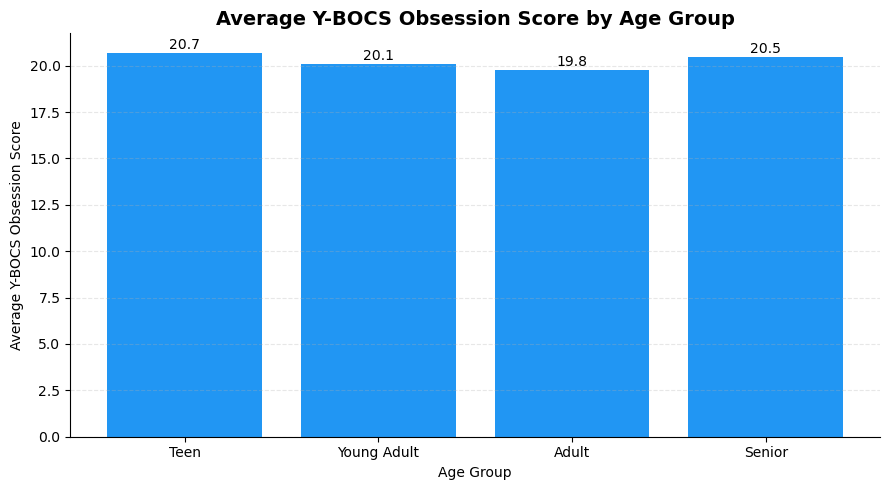

In [22]:
# 5. One professional chart with: - Value labels on bars - No top or right borders - Subtle grid - Proper title and axis labels

# Calculate average obsession score by age group
agegroup_score = df.groupby('AgeGroup', observed=False)['Y-BOCS Score (Obsessions)'].mean()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    agegroup_score.index,
    agegroup_score.values,
    color='#2196F3'
)

# Add value labels on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.1f}',
        ha='center'
)
plt.title('Average Y-BOCS Obsession Score by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Y-BOCS Obsession Score')

plt.grid(axis='y', linestyle='--', alpha=0.3)

# Remove top and right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Subplot:

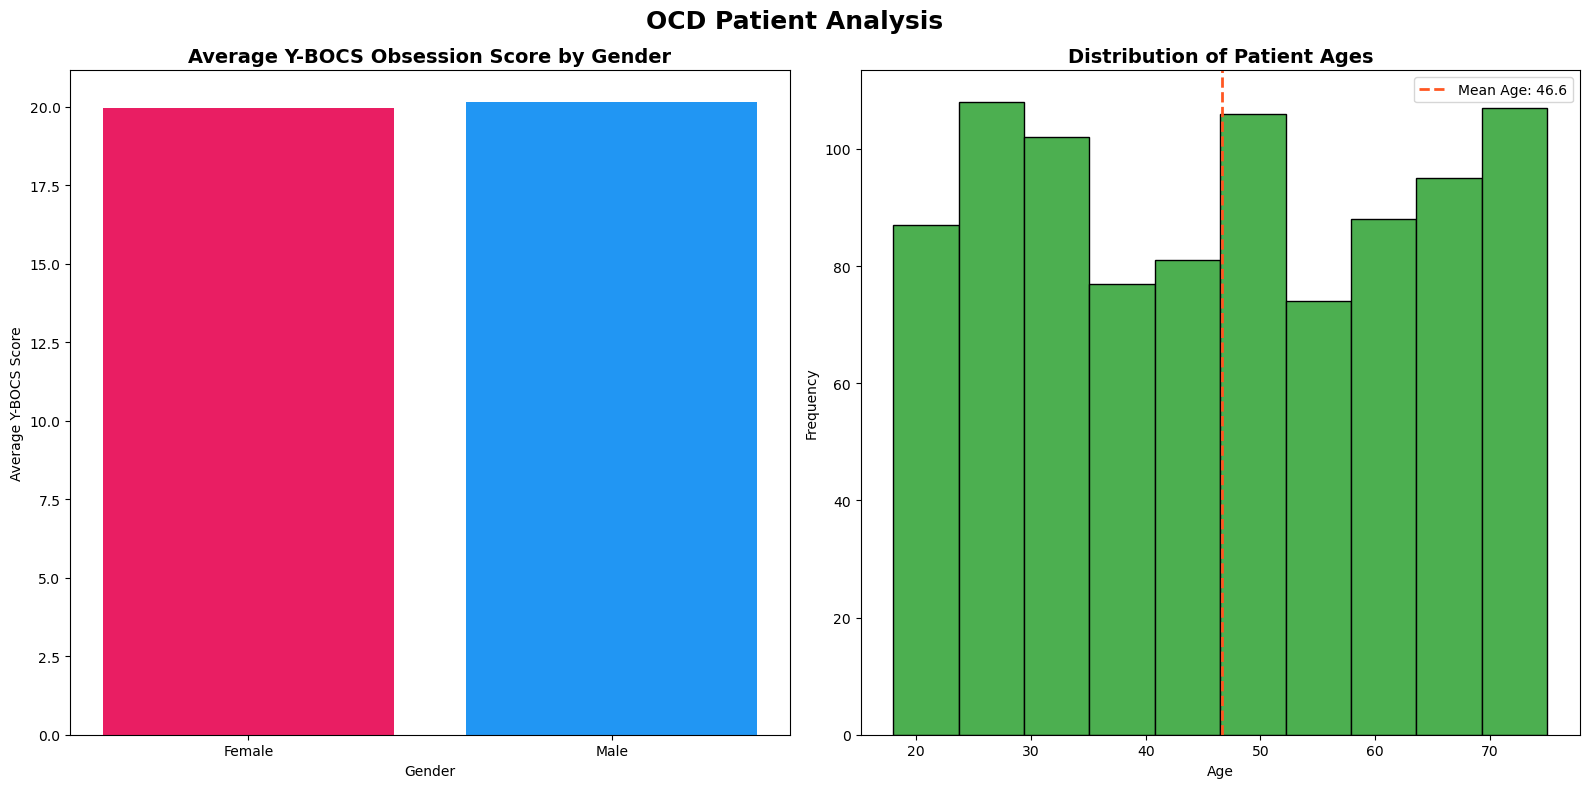

In [24]:
# 6. A subplot combining any 2 charts side by side

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Chart 1: Bar Chart
avg_score = df.groupby('Gender')['Y-BOCS Score (Obsessions)'].mean()

ax[0].bar(
    avg_score.index,
    avg_score.values,
    color=['#E91E63', '#2196F3']
)

ax[0].set_title('Average Y-BOCS Obsession Score by Gender', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Gender')
ax[0].set_ylabel('Average Y-BOCS Score')

# Chart 2: Histogram
mean_age = df['Age'].mean()

ax[1].hist(
    df['Age'],
    bins=10,
    color='#4CAF50',
    edgecolor='black'
)
ax[1].axvline(
    mean_age,
    color='#FF5722',
    linestyle='--',
    linewidth=2,
    label=f'Mean Age: {mean_age:.1f}'
)

ax[1].set_title('Distribution of Patient Ages', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Age')
ax[1].set_ylabel('Frequency')

plt.suptitle("OCD Patient Analysis", fontsize=18, fontweight="bold")

ax[1].legend()
plt.tight_layout()

plt.show()

### The subplot provides a quick comparison of OCD obsession severity by gender alongside the age distribution of the patients, giving both clinical-score and demographic information in one figure.

### Chart Saved:

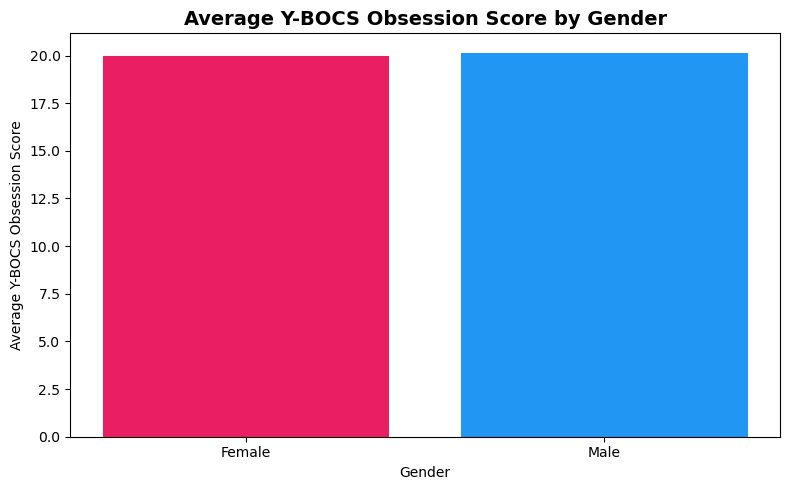

Chart saved


In [27]:
# 7. Save at least 2 charts using savefig() All charts must have titles and labelled axes

avg_score = df.groupby('Gender')['Y-BOCS Score (Obsessions)'].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    avg_score.index,
    avg_score.values,
    color=['#E91E63', '#2196F3']
)
plt.title('Average Y-BOCS Obsession Score by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Y-BOCS Obsession Score')

plt.savefig('obsession_score_by_gender.png', dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

print('Chart saved')

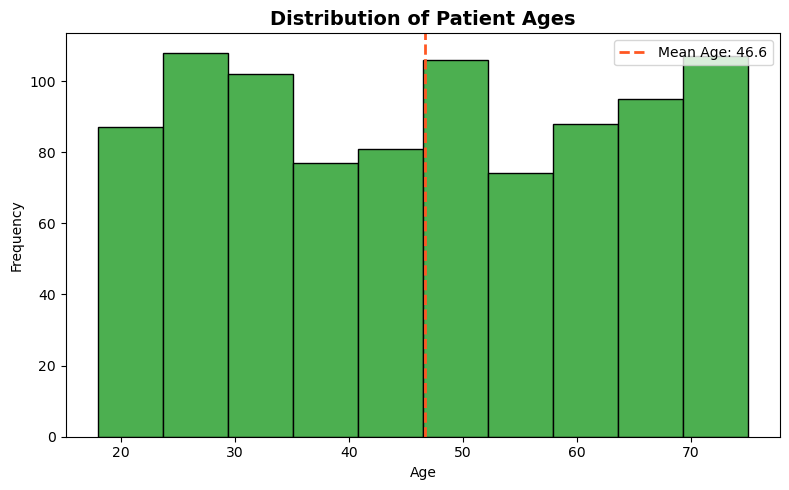

Chart saved


In [28]:
# To create and save histogram chart
mean_age = df['Age'].mean()

plt.figure(figsize=(8, 5))

plt.hist(
    df['Age'],
    bins=10,
    color='#4CAF50',
    edgecolor='black'
)

plt.axvline(
    mean_age,
    color='#FF5722',
    linestyle='--',
    linewidth=2,
    label=f'Mean Age: {mean_age:.1f}'
)

plt.title('Distribution of Patient Ages', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')

plt.legend()
plt.tight_layout()

plt.show()

print('Chart saved')